In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better plots
sns.set(style="whitegrid")

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


In [2]:
#  Load dataset

data_path = "../data/heart.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully ✅")
df.head()

Dataset loaded successfully ✅


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Display the shape of the dataset
df.shape

(1025, 14)

In [7]:
# Display the columns name of the dataset
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
# Display basic information about the dataset
# This helps understand number of entries, column types, and memory usage

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
# Generate summary statistics for numerical features
# Useful for identifying ranges, averages, and potential outliers

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
# Count missing values in each column
# Ensures data quality before building models

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

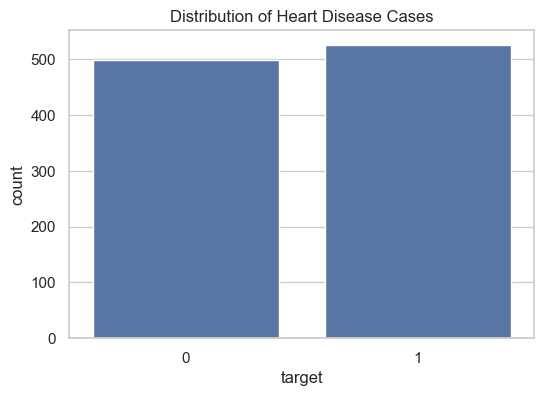

In [11]:
# Visualize distribution of the target variable (presence of heart disease)
# Helps detect class imbalance

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Distribution of Heart Disease Cases")
plt.show()

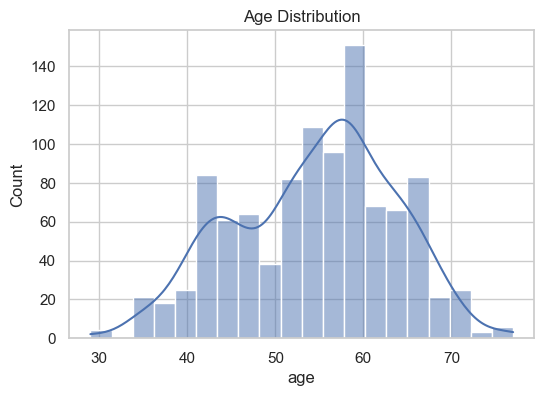

In [12]:
# Analyze distribution of patient ages
# Provides insight into demographics of the dataset

plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

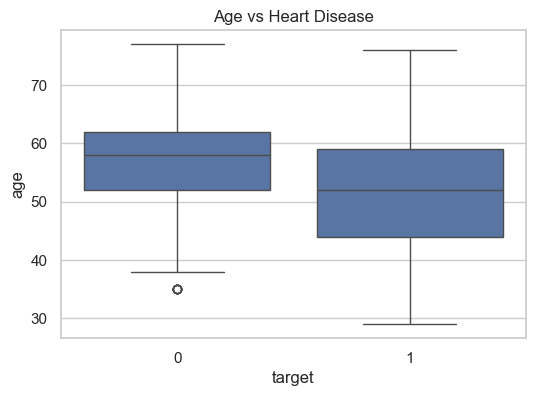

In [13]:
# Compare age distribution between patients with and without heart disease
# Helps identify whether age is a significant risk factor

plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

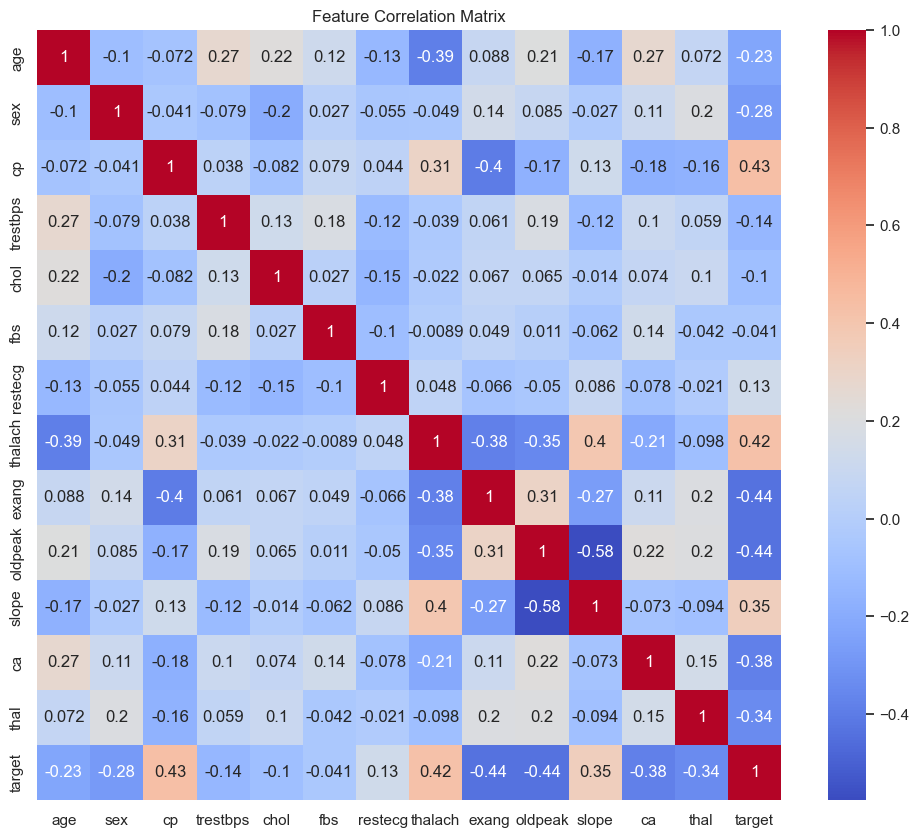

In [14]:
# Compute correlations between all features
# Useful for identifying strong relationships and multicollinearity

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

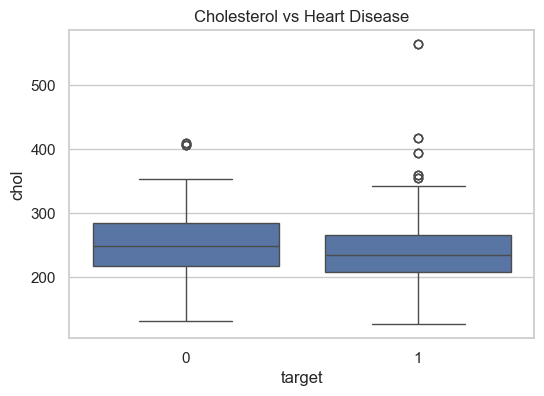

In [15]:
# Examine how cholesterol levels differ between groups
# Demonstrates how medical features vary with disease presence

plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

In [16]:
# Separate input features (X) and target variable (y)
# X contains medical attributes, y indicates presence of heart disease

X = df.drop("target", axis=1)
y = df["target"]

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [17]:
# Split dataset into training and testing subsets
# Training data is used to learn patterns, testing data evaluates performance

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 820
Testing samples: 205


### Data was split into training and testing sets using stratified sampling to preserve class distribution.

In [18]:
# Standardize numerical features so they have mean 0 and variance 1
# Helps algorithms that are sensitive to feature scales

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[ 0.81162633, -1.50996689, -0.90957214,  0.31472862,  0.89579058,
         2.34689934,  0.926946  , -1.92115501, -0.71813066,  0.69652503,
        -0.59754229,  2.20730061, -0.56245085],
       [ 0.15224695, -1.50996689, -0.90957214,  3.76764257,  0.77911537,
         2.34689934, -0.98284224, -0.72536159,  1.39250426,  2.47581015,
        -2.1987994 ,  1.22840039,  1.0906305 ],
       [ 0.26214351,  0.66226618,  1.04803719, -0.24219298, -0.36819094,
        -0.42609412, -0.98284224,  0.02754538, -0.71813066, -0.57439291,
        -0.59754229,  0.24950018,  1.0906305 ],
       [ 0.26214351,  0.66226618,  1.04803719,  0.98303455, -2.37111551,
         2.34689934,  0.926946  ,  1.04618421, -0.71813066, -0.74384864,
         1.00371482,  0.24950018,  1.0906305 ],
       [-0.28733931, -1.50996689,  1.04803719,  0.2033443 , -1.00990464,
        -0.42609412, -0.98284224,  0.86902963, -0.71813066, -0.8285765 ,
        -0.59754229, -0.72940004, -0.56245085]])

In [20]:
# Verify dimensions after preprocessing
# Ensures data is ready for model training

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (820, 13)
X_test: (205, 13)
y_train: (820,)
y_test: (205,)


In [21]:
# Import the Random Forest classifier
# This algorithm builds multiple decision trees and combines their predictions

from sklearn.ensemble import RandomForestClassifier

In [22]:
# Create a Random Forest model with reproducible results
# n_estimators defines the number of trees in the forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [23]:
# Train the model using the training dataset
# The model learns relationships between features and disease outcome

rf_model.fit(X_train_scaled, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [24]:
# Use the trained model to predict outcomes for unseen test data
# These predictions will be used to evaluate performance

y_pred = rf_model.predict(X_test_scaled)

y_pred[:10]

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 1])

In [25]:
# Obtain probability estimates for each class
# Useful for risk scoring rather than just binary output

y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

y_prob[:10]

array([0.04, 0.71, 0.  , 0.88, 0.01, 0.  , 0.87, 0.08, 1.  , 0.71])

In [26]:
# Import evaluation metrics used to assess classification performance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [27]:
# Calculate standard classification metrics
# These quantify how well the model distinguishes diseased vs healthy cases

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
ROC-AUC:   1.000


In [28]:
# Display a comprehensive report with per-class metrics
# Useful for identifying strengths and weaknesses of the model

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



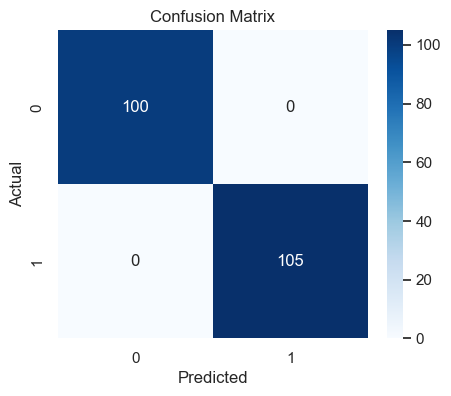

In [29]:
# Visualize prediction outcomes to understand error patterns
# Shows true vs predicted classes

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

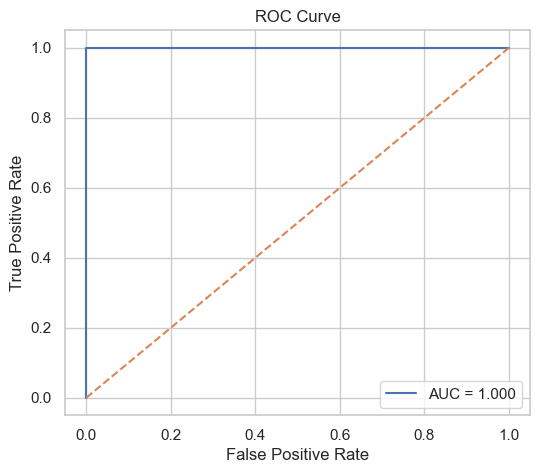

In [30]:
# Plot the Receiver Operating Characteristic curve
# Illustrates trade-off between true positive rate and false positive rate

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [52]:
# Import SHAP for model interpretability

import shap

In [68]:
# Define prediction function returning probability of heart disease
# SHAP will explain this function instead of the raw model

def predict_proba(X):
    return rf_model.predict_proba(X)[:, 1]

In [69]:
# Create model-agnostic explainer using training data as background

explainer = shap.Explainer(
    predict_proba,
    X_train_scaled
)

In [70]:
# Compute SHAP values for test data

shap_values = explainer(X_test_scaled)

PermutationExplainer explainer: 206it [00:33,  4.80it/s]                         


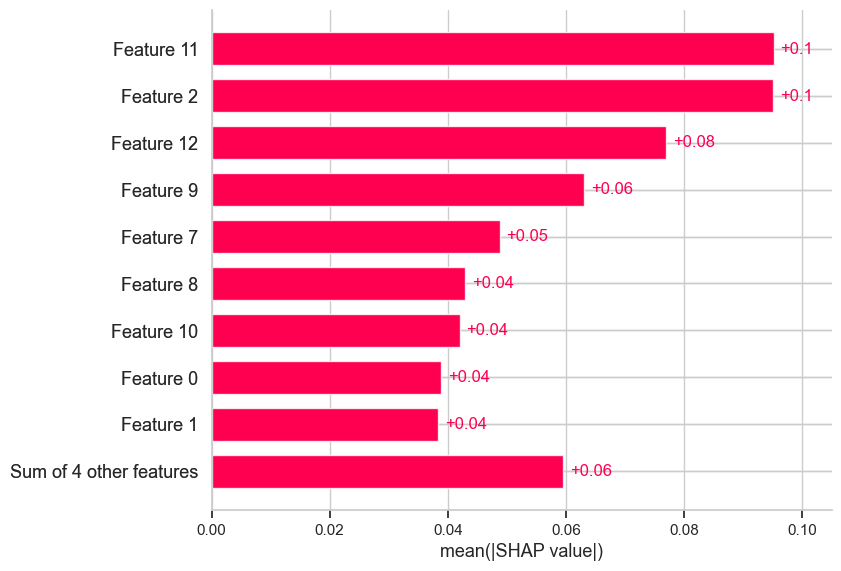

In [71]:
# Display overall importance of features

shap.plots.bar(shap_values)

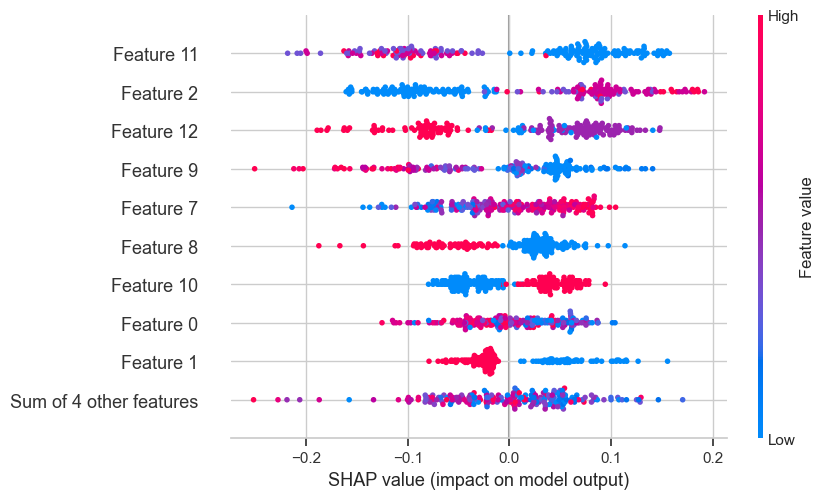

In [72]:
# Show distribution of feature effects across samples

shap.plots.beeswarm(shap_values)

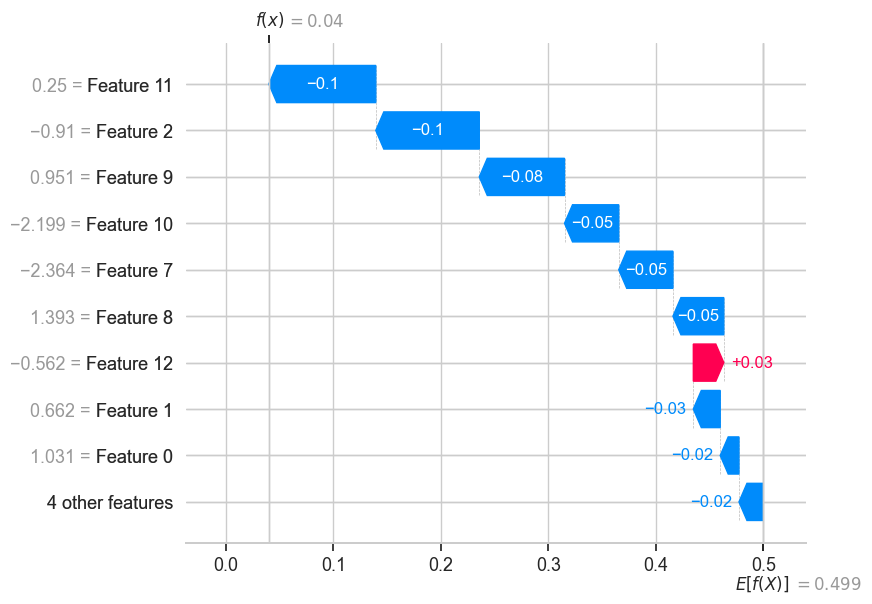

In [73]:
# Explain prediction for one patient

sample_index = 0

shap.plots.waterfall(shap_values[sample_index])

### SHAP explanations were computed on the predicted probability of disease using a model-agnostic explainer.

In [74]:
# Import joblib to save trained objects efficiently

import joblib

In [75]:
# Save the trained Random Forest model to disk
# This allows reuse without retraining

joblib.dump(rf_model, "../models/rf_model.pkl")

['../models/rf_model.pkl']

In [76]:
# Save the fitted scaler used during preprocessing
# Required to transform new input data correctly

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']